<a href="https://colab.research.google.com/github/Leito-uwu/Detector-de-Cuellos-de-Botellas-Internos/blob/main/Centrado_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# CELDA 1: Configuración del entorno
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# Montar Drive (necesario para cargar tu dataset)
drive.mount('/content/drive')

# Función auxiliar para mostrar imágenes cómodamente en Colab
def mostrar_imagen(titulo, imagen_bgr, cmap=None):
    plt.figure(figsize=(10, 10))
    if cmap == 'gray':
        plt.imshow(imagen_bgr, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB))
    plt.title(titulo)
    plt.axis('off')
    plt.show()

Mounted at /content/drive


In [7]:
# CELDA: Módulo Detector - Aislando el Contorno Blanco
import cv2
import numpy as np
import matplotlib.pyplot as plt

def trabajar_con_contorno_blanco(imagen_bgr_original, debug=False):
    """
    Binariza la imagen y separa la botella de la máquina usando morfología
    para extraer únicamente el Bounding Box de la botella cruda.
    """
    alto_orig, ancho_orig = imagen_bgr_original.shape[:2]

    escala = 800.0 / ancho_orig
    nuevo_ancho = 800
    nuevo_alto = int(alto_orig * escala)
    imagen_trabajo = cv2.resize(imagen_bgr_original, (nuevo_ancho, nuevo_alto))
    centro_foto_x = nuevo_ancho // 2
    centro_foto_y = nuevo_alto // 2

    # 1. Filtros (Los que ya demostraron funcionar en tu imagen)
    gris = cv2.cvtColor(imagen_trabajo, cv2.COLOR_BGR2GRAY)
    gris_suavizado = cv2.medianBlur(gris, 15)

    # 2. Binarización Adaptativa (Convierte el cuello negro a blanco)
    binarizada = cv2.adaptiveThreshold(gris_suavizado, 255,
                                      cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      cv2.THRESH_BINARY_INV, 201, 10)

    # ---------------------------------------------------------
    # 3. NUEVO PASO CLAVE: DESCONECTAR LA MÁQUINA DE LA BOTELLA
    # Usamos un kernel (pincel) elíptico grande para romper las uniones.
    # Si la máquina sigue pegada, aumenta este número (ej. a 25, 25).
    # ---------------------------------------------------------
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    binarizada_limpia = cv2.morphologyEx(binarizada, cv2.MORPH_OPEN, kernel)

    # 4. Encontrar contornos en la imagen ya limpia y separada
    contornos, _ = cv2.findContours(binarizada_limpia, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    mejor_contorno = None
    mejor_distancia = float('inf')

    for c in contornos:
        area = cv2.contourArea(c)
        if area < 10000: continue # Ignorar basura pequeña

        M = cv2.moments(c)
        if M["m00"] == 0: continue

        cx_contorno = int(M["m10"] / M["m00"])
        cy_contorno = int(M["m01"] / M["m00"])

        distancia_al_centro = np.sqrt((cx_contorno - centro_foto_x)**2 + (cy_contorno - centro_foto_y)**2)

        # Nos quedamos con la forma blanca más cercana al centro de la foto
        if distancia_al_centro < mejor_distancia:
            mejor_distancia = distancia_al_centro
            mejor_contorno = c

    if mejor_contorno is not None:
        # Extraer Bounding Box y re-escalar al tamaño original
        x, y, w, h = cv2.boundingRect(mejor_contorno)
        bbox_orig = (int(x/escala), int(y/escala), int(w/escala), int(h/escala))

        if debug:
            plt.figure(figsize=(20, 5))
            plt.subplot(1, 4, 1); plt.imshow(gris_suavizado, cmap='gray'); plt.title("1. Blur")
            plt.subplot(1, 4, 2); plt.imshow(binarizada, cmap='gray'); plt.title("2. Binarizado (PEGADO)")
            plt.subplot(1, 4, 3); plt.imshow(binarizada_limpia, cmap='gray'); plt.title("3. Limpio (SEPARADO)")

            # Dibujar el contorno ganador sobre la limpia para verificar
            img_verificacion = cv2.cvtColor(binarizada_limpia, cv2.COLOR_GRAY2BGR)
            cv2.drawContours(img_verificacion, [mejor_contorno], -1, (0, 255, 0), 5)
            plt.subplot(1, 4, 4); plt.imshow(img_verificacion); plt.title("4. Contorno Elegido")
            plt.show()

        return bbox_orig
    else:
        return None

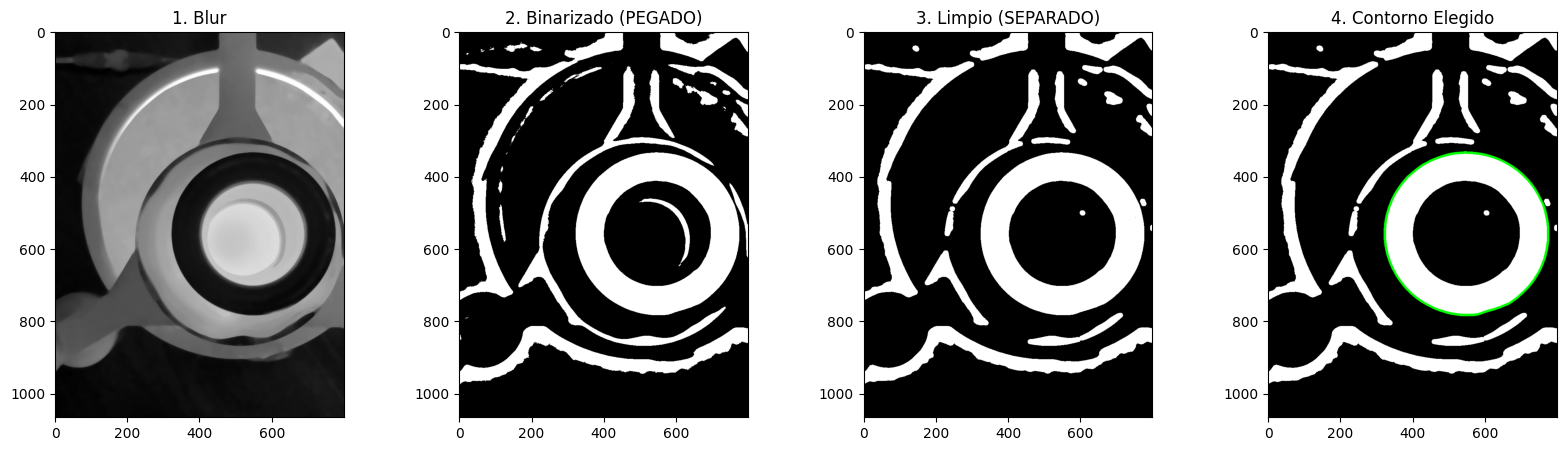

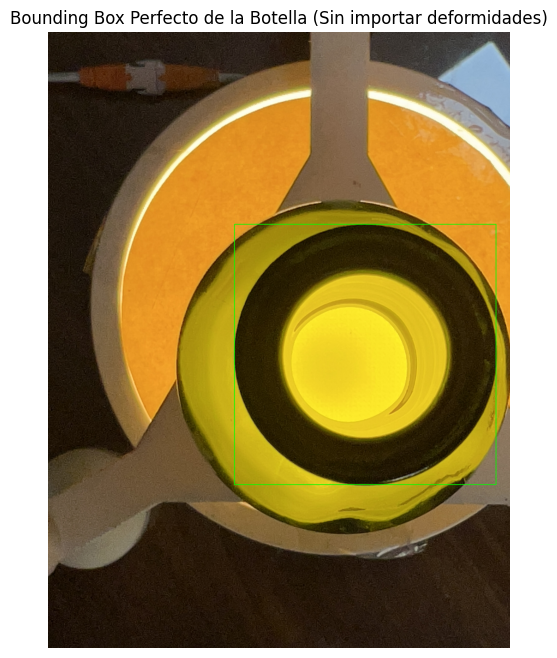

In [20]:
# --- (Ajusta tu ruta aquí) ---
ruta_imagen = '/content/drive/MyDrive/PPP/Dataset/Botellas_Buenas_1/B_B0785.JPG' # Usa la imagen donde fallaba el cuadro verde
# -----------------------------

imagen_original = cv2.imread(ruta_imagen)

if imagen_original is not None:
    # Llamar a la función con debug=True para ver la separación
    bbox = trabajar_con_contorno_blanco(imagen_original, debug=True)

    if bbox is not None:
        x, y, w, h = bbox

        imagen_visualizacion = imagen_original.copy()
        # Dibujar la Caja Delimitadora (Bounding Box) en color verde
        cv2.rectangle(imagen_visualizacion, (x, y), (x + w, y + h), (0, 255, 0), 4)

        plt.figure(figsize=(8, 8))
        plt.imshow(cv2.cvtColor(imagen_visualizacion, cv2.COLOR_BGR2RGB))
        plt.title("Bounding Box Perfecto de la Botella (Sin importar deformidades)")
        plt.axis('off')
        plt.show()
    else:
        print("No se encontró ningún contorno válido.")
else:
    print("Error cargando la imagen.")

In [37]:
# CELDA: Script de Validación Masiva
import os
import cv2
import shutil
from tqdm import tqdm # Para la barra de progreso

# ==========================================
# CONFIGURACIÓN DE RUTAS (Ajusta a tu Drive)
# ==========================================
# Carpeta que quieres evaluar (ej. tus botellas malas)
RUTA_EVALUAR = '/content/drive/My Drive/dataset_pasantia/malas/'

# Carpeta donde se guardarán las fotos que el algoritmo NO pudo detectar
RUTA_ERRORES = '/content/drive/My Drive/dataset_pasantia/errores_deteccion/'

# Crear la carpeta de errores si no existe
if not os.path.exists(RUTA_ERRORES):
    os.makedirs(RUTA_ERRORES)
# ==========================================

def validacion_masiva_contornos(ruta_origen, ruta_errores):
    if not os.path.exists(ruta_origen):
        print(f"Error: La ruta {ruta_origen} no existe.")
        return

    # Obtener todas las imágenes de la carpeta
    archivos = [f for f in os.listdir(ruta_origen) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    total_img = len(archivos)

    if total_img == 0:
        print("La carpeta está vacía.")
        return

    print(f"Iniciando validación de {total_img} imágenes...")

    # Contadores
    exitos = 0
    fallos = 0
    tiempos_procesamiento = [] # Para medir si es lo suficientemente rápido para la industria

    # Iterar con barra de progreso
    for nombre_archivo in tqdm(archivos):
        ruta_completa = os.path.join(ruta_origen, nombre_archivo)
        imagen = cv2.imread(ruta_completa)

        if imagen is None:
            continue

        # --- APLICAR TU FUNCIÓN ROBUSTA ---
        # Iniciamos temporizador (opcional para medir latencia)
        e1 = cv2.getTickCount()

        # Llamamos a la función (debug=False para que no se pause mostrando gráficos)
        bbox = trabajar_con_contorno_blanco(imagen, debug=False)

        e2 = cv2.getTickCount()
        tiempo_ms = (e2 - e1) / cv2.getTickFrequency() * 1000
        tiempos_procesamiento.append(tiempo_ms)
        # ----------------------------------

        # Lógica de validación
        if bbox is not None:
            exitos += 1
        else:
            fallos += 1
            # Copiar la imagen problemática a la carpeta de errores
            ruta_destino_error = os.path.join(ruta_errores, nombre_archivo)
            shutil.copy(ruta_completa, ruta_destino_error)

    # --- REPORTE FINAL ---
    tasa_exito = (exitos / total_img) * 100
    tiempo_promedio = sum(tiempos_procesamiento) / len(tiempos_procesamiento)

    print("\n" + "="*50)
    print(" REPORTE DE VALIDACIÓN INDUSTRIAL")
    print("="*50)
    print(f"Total procesadas  : {total_img}")
    print(f"Detecciones OK    : {exitos} ({tasa_exito:.2f}%)")
    print(f"Fallos (No bbox)  : {fallos} ({(fallos/total_img)*100:.2f}%)")
    print(f"Tiempo prom/img   : {tiempo_promedio:.2f} ms")
    print("="*50)

    if fallos > 0:
        print(f"⚠️ Las {fallos} imágenes que fallaron se copiaron a:")
        print(f"   {ruta_errores}")
        print("   Recomiendo abrirlas y pasarles la función con debug=True para afinar.")

# Ejecutar
validacion_masiva_contornos(RUTA_EVALUAR, RUTA_ERRORES)

Iniciando evaluación de 1512 imágenes...



100%|██████████| 1512/1512 [08:41<00:00,  2.90it/s]


 REPORTE DE VALIDACIÓN MASIVA
Total de imágenes procesadas : 1512
Imágenes que FALLARON        : 1007 (66.60%)
Radios MAYORES a 700 px  : 462 (30.56%)
Radios MENORES o iguales     : 43 (2.84%)


Imagen cargada correctamente. Resolución: 3024x4032
¡Centro exacto detectado exitosamente!
X (Centro): 1802 px, Y (Centro): 3022 px, Radio Agujero: 232 px


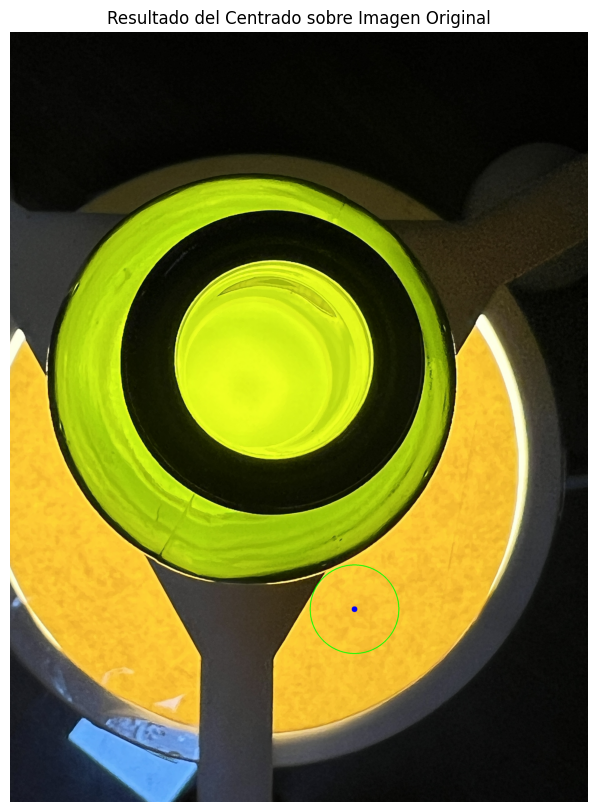

In [18]:
# CELDA 3: Prueba del centrado (Como main.py)

# Ruta a tu imagen de prueba en Drive
ruta_imagen_drive = '/content/drive/MyDrive/PPP/Dataset/Botellas_Buenas_1/B_B0001.JPG'
# ruta_imagen_drive = 'image_0.png' # Si la subiste directamente a Colab local

# 1. Cargar imagen ORIGINAL (intacta)
imagen_original = cv2.imread(ruta_imagen_drive)

if imagen_original is not None:
    print(f"Imagen cargada correctamente. Resolución: {imagen_original.shape[1]}x{imagen_original.shape[0]}")

    # 2. Llamar al Módulo Detector
    # Observa cómo pasamos la imagen_original, pero el detector interna y
    # temporalmente la filtrará sin alterarla para nosotros.
    cx, cy, r_agujero = encontrar_centro_agujero_brillante(imagen_original)

    if cx is not None:
        print(f"¡Centro exacto detectado exitosamente!")
        print(f"X (Centro): {cx} px, Y (Centro): {cy} px, Radio Agujero: {r_agujero} px")

        # 3. Visualizar el resultado sobre la imagen original
        imagen_visualizacion = imagen_original.copy()
        # Dibujar un punto azul pequeño justo en las coordenadas (cx, cy)
        cv2.circle(imagen_visualizacion, (cx, cy), 15, (255, 0, 0), -1) # Punto azul relleno
        # Dibujar el contorno del agujero brillante detectado
        cv2.circle(imagen_visualizacion, (cx, cy), r_agujero, (0, 255, 0), 4) # Círculo verde

        mostrar_imagen("Resultado del Centrado sobre Imagen Original", imagen_visualizacion)

    else:
        print("No se pudo detectar el centro del agujero brillante. Revisa los parámetros 'threshold' o 'HoughCirclesRadius'.")
else:
    print("Error cargando la imagen. Revisa la ruta en Drive.")